In [1]:
#Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score

In [2]:
# Load the dataset into a pandas DataFrame
import os

csv_file_name = 'london_merged.csv'

if os.path.exists(csv_file_name):
    df = pd.read_csv(csv_file_name)
    print("Dataset loaded successfully!")
    display(df.head())
else:
    print(f"Error: {csv_file_name} not found. Please check the extracted file name.")


Dataset loaded successfully!


,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [3]:
# general look at the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


In [4]:
# check statiscs of data
df.describe()

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
std,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911
min,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000


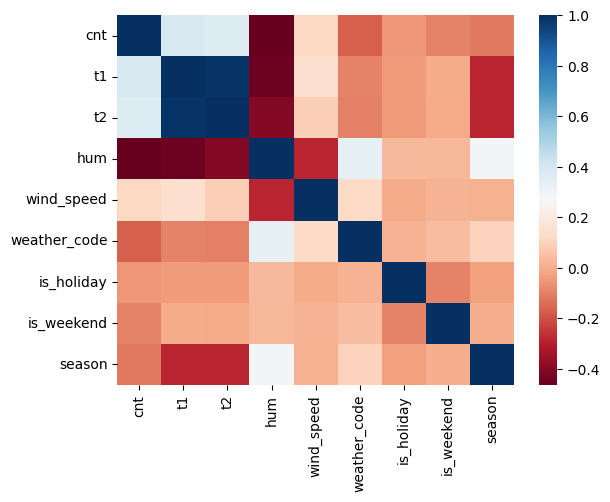

In [5]:
# Analyze the correlation between features with heatmap
sns.heatmap(df.iloc[:,:].corr(numeric_only=True), cmap='RdBu')
plt.show()

In [6]:
# use the IQR method to detect outliers
Q1 = np.percentile(df['cnt'], 25, method='midpoint')
Q3 = np.percentile(df['cnt'], 75, method='midpoint')
IQR = Q3 - Q1
print(IQR)

# compute the upper and lower bounds then sum the total no. of point above or below the bounds
upper = Q3+1.5*IQR
upper_array = np.array(df['cnt'] >= upper)
print("Upper Bound:", upper)
print(upper_array.sum())

lower = Q1-1.5*IQR
lower_array = np.array(df['cnt'] <= lower)
print("Lower Bound:", lower)
print(lower_array.sum())

1414.5
Upper Bound: 3793.25
675
Lower Bound: -1864.75
0


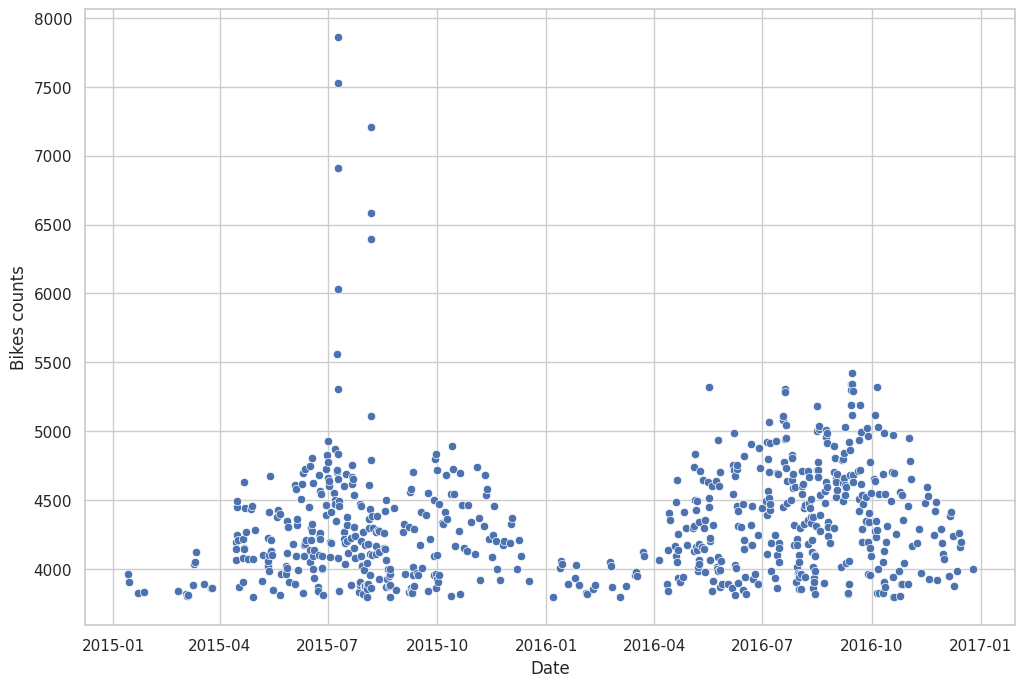

In [7]:
# pick up and plot the outliers
upper_array = np.where(df['cnt'] >= upper)[0]
lower_array = np.where(df['cnt'] <= lower)[0]
outlier = np.array(df['cnt'][upper_array])
time_out = np.array(df['timestamp'][upper_array])
time_out = pd.to_datetime(time_out)

plt.figure(figsize=(12, 8))
sns.set(style='whitegrid')
p = (sns.scatterplot(x=time_out, y=outlier ))
p.set_xlabel("Date")
p.set_ylabel("Bikes counts")
#plt.savefig("out.pdf", bbox_inches="tight")
plt.show()

In [8]:
# normalize the timestamp column into year,month,day,hour
df2 =df.copy()
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
df2['year'] = df2['timestamp'].dt.year
df2['month'] = df2['timestamp'].dt.month
df2['dayweek'] = df2['timestamp'].dt.dayofweek
#df2['day'] = df2['timestamp'].dt.day
df2['hour'] = df2['timestamp'].dt.hour
df2.drop(['timestamp'], axis='columns', inplace=True)

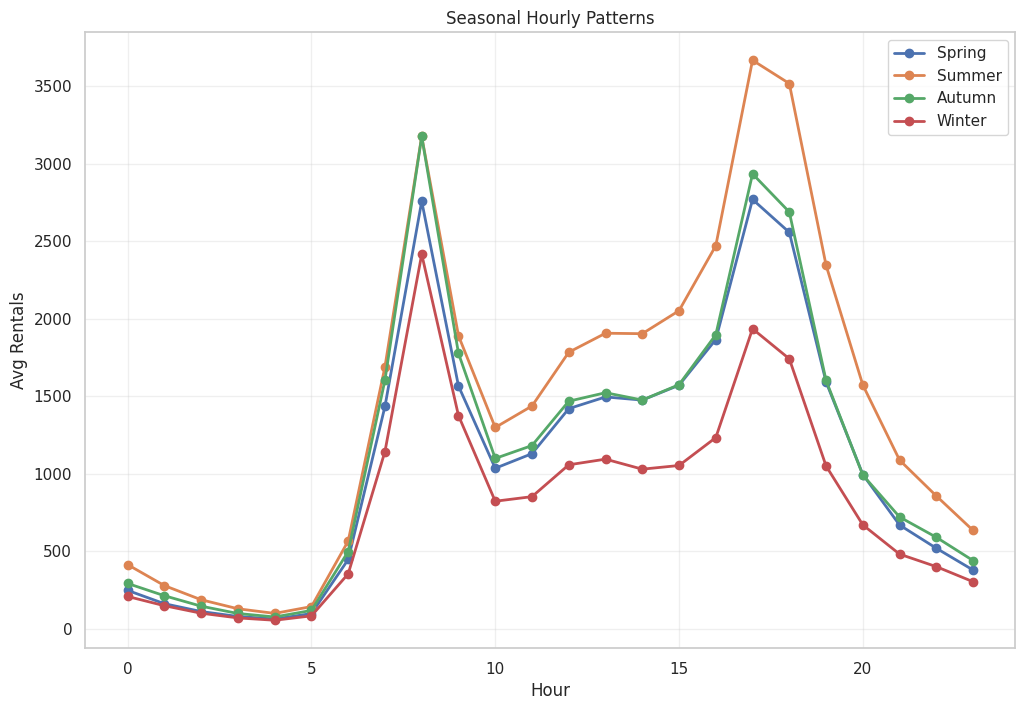

In [9]:
#tacke a look at seasonal hourly demand
season_names = ['Spring', 'Summer', 'Autumn', 'Winter']

# Convert 'timestamp' to datetime and extract 'hour' before grouping
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour

fig, axes = plt.subplots(1, 1, figsize=(12,8))
for s, name in enumerate(season_names):
    hourly = df[df['season'] == s].groupby('hour')['cnt'].mean()
    axes.plot(hourly.index, hourly.values, marker='o', linewidth=2, label=name)

    axes.set_title('Seasonal Hourly Patterns')
    axes.set_xlabel('Hour')
    axes.set_ylabel('Avg Rentals')
    axes.legend()
    axes.grid(alpha=0.3)

In [10]:
#drop outliers, t2 feature and the summer time chnge on 2015-03-29
print("data_shape_before = {}".format(df2.shape))
df2.drop(['t2'], axis='columns', inplace=True)
df2 = df2[df2['cnt'] != 0]  # drop time change row
upper_outlier = np.where(df2['cnt'] >= 5500)[0]
df2.drop(upper_outlier, inplace=True)
print("data_shape_after = {}".format(df2.shape))
df2.head()

data_shape_before = (17414, 13)
data_shape_after = (17405, 12)


,cnt,t1,hum,wind_speed,weather_code,is_holiday,is_weekend,season,year,month,dayweek,hour
0,182,3.0,93.0,6.0,3.0,0.0,1.0,3.0,2015,1,6,0
1,138,3.0,93.0,5.0,1.0,0.0,1.0,3.0,2015,1,6,1
2,134,2.5,96.5,0.0,1.0,0.0,1.0,3.0,2015,1,6,2
3,72,2.0,100.0,0.0,1.0,0.0,1.0,3.0,2015,1,6,3
4,47,2.0,93.0,6.5,1.0,0.0,1.0,3.0,2015,1,6,4


In [11]:
#apply one-hot encoding to 'year' and 'weather_code' columns
from sklearn.preprocessing import OneHotEncoder

#One-hot encode 'year'
enc_year = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
year_encoded = enc_year.fit_transform(df2[['year']])
year_df = pd.DataFrame(year_encoded, columns=enc_year.get_feature_names_out(['year']), index=df2.index)

# One-hot encode 'weather_code'
enc_weather = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
weather_encoded = enc_weather.fit_transform(df2[['weather_code']])
weather_df = pd.DataFrame(weather_encoded, columns=enc_weather.get_feature_names_out(['weather_code']), index=df2.index)

# Drop the original 'year' and 'weather_code' columns and concatenate the new one-hot encoded columns
df2 = pd.concat([df2.drop([ 'weather_code'], axis=1), weather_df], axis=1)
#df2 = pd.concat([df2.drop(['year', 'weather_code'], axis=1), year_df, weather_df], axis=1)
print("One-hot encoding applied to 'year' and 'weather_code' columns.")

One-hot encoding applied to 'year' and 'weather_code' columns.


In [12]:
#define a function to create cyclic features from temporal columns
def encode(data, col, period):
    data[col + '_sin'] = np.sin(2 * np.pi * data[col]/period)
    data[col + '_cos'] = np.cos(2 * np.pi * data[col]/period)
    return data

In [13]:
#cycle encoding of date features
df2 = encode(df2, 'month', 12)
df2 = encode(df2, 'hour', 24)
df2 = encode(df2, 'dayweek', 7)
#df2 = encode(df2, 'day', 31)
df2.drop(['month'], axis='columns', inplace=True)
df2.drop(['hour'], axis='columns', inplace=True)
df2.drop(['dayweek'], axis='columns', inplace=True)

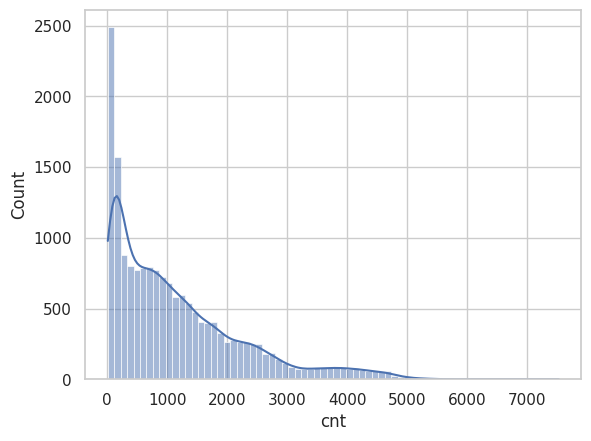

In [ ]:
#plot the distribution of the target column
sns.histplot(df2['cnt'], kde=True)
plt.show()

In [ ]:
# apply log-transformation to 'cnt' column since the distribution is right skewd
df2['cnt'] = np.log1p(df2['cnt'])

In [ ]:
#train_test split
y = df2['cnt']
X = df2.drop(['cnt'], axis='columns')
test_size = 0.2
SEED = 60

XTrain, XTest, ytrain, ytest = train_test_split(X, y, test_size=test_size, random_state= SEED)

print(f"Data split successfully: ")
print(f"  X_train shape: {XTrain.shape}")
print(f"  X_test shape: {XTest.shape}")
print(f"  y_train shape: {ytrain.shape}")
print(f"  y_test shape: {ytest.shape}")




Data split successfully: 
  X_train shape: (13924, 20)
  X_test shape: (3481, 20)
  y_train shape: (13924,)
  y_test shape: (3481,)


In [ ]:
#apply standard scaler to specific columns
# Initialize StandardScaler
scaler_new = StandardScaler()

# Columns to be scaled
cols_to_scale_new = ['t1','hum', 'wind_speed']

# Fit the scaler only on the training data for the specified columns
scaler_new.fit(XTrain[cols_to_scale_new])

# Transform the specified columns in both training and test sets
XTrain_scaled_part = scaler_new.transform(XTrain[cols_to_scale_new])
XTest_scaled_part = scaler_new.transform(XTest[cols_to_scale_new])

# Update the original DataFrames with the scaled values
XTrain[cols_to_scale_new] = pd.DataFrame(XTrain_scaled_part, columns=cols_to_scale_new, index=XTrain.index)
XTest[cols_to_scale_new] = pd.DataFrame(XTest_scaled_part, columns=cols_to_scale_new, index=XTest.index)

print("Standard scaling applied to 'hum' and 'wind_speed' columns in a new cell.")
#print(f"X_train head after selective scaling:\n{XTrain.head()}")
#print(f"X_test head after selective scaling:\n{XTest.head()}")

Standard scaling applied to 'hum' and 'wind_speed' columns in a new cell.


In [ ]:
# tryout different models

# reg = MLPRegressor(hidden_layer_sizes=(20,20,20),activation="relu", solver='adam',
#                    alpha=0.001, batch_size='auto', learning_rate='constant',
#                    learning_rate_init=0.001, tol=0.0001, random_state=SEED,
#                    max_iter=10000)

reg = RandomForestRegressor(n_estimators=300, criterion='squared_error',
                           max_depth=30, min_samples_split=2, min_samples_leaf=1,
                            min_weight_fraction_leaf=0.0, max_features='sqrt',
                            max_leaf_nodes=None, min_impurity_decrease=0.0,
                            bootstrap=True, oob_score=False, n_jobs=None,
                            random_state= SEED, verbose=0, warm_start=False,
                            ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
reg.fit(XTrain, ytrain)

# Make predictions on the training data
ytrain_pred = reg.predict(XTrain)

# Calculate the accuracy of the model on the training data
train_score = mean_absolute_percentage_error(ytrain, ytrain_pred)
print(f"Model Training Accuracy: {train_score:.4f}")
# Calculate the accuracy of the model on the test data
y_pred = reg.predict(XTest)
test_score = mean_absolute_percentage_error(ytest, y_pred)
print(f"Model Test Accuracy: {test_score:.4f}")

Model Training Accuracy: 0.0118
Model Test Accuracy: 0.0312


In [ ]:
# Use grid search and cross validation for finetuning the hyperparameters of the model
mlpreg = MLPRegressor(random_state=SEED)
rfreg = RandomForestRegressor(random_state=SEED)
regressors = [mlpreg,rfreg]

# Define proper parameter grid for MLPRegressor
param_MLP = {
    'hidden_layer_sizes': [(20,), (20,20), (20,20,20)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.001,0.01,0.1],
    'tol': [0.0001],
    'learning_rate_init': [0.001,0.01,0.1],
    'max_iter' :[10000]
}

param_rf = {
    "n_estimators":[100,200,300,500],
    "max_depth":[5,10,20,30,None],
    "max_features":["sqrt","log2"]
}

for reg in regressors:
    name = type(reg).__name__

    # Use the appropriate parameter grid for the regressor
    if reg == mlpreg:
       param_grid = param_MLP

    elif reg == rfreg:
         param_grid = param_rf


    gs = GridSearchCV(reg, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_percentage_error')

    gs.fit(XTrain, ytrain)

    print("GridSearch Score", name,
          cross_val_score(gs.best_estimator_, XTrain, ytrain,scoring='neg_mean_absolute_percentage_error').mean())

    print("Beste Parameter:", gs.best_params_)
    print()

GridSearch Score MLPRegressor -0.0739260252884079
Beste Parameter: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (20, 20, 20), 'learning_rate_init': 0.001, 'max_iter': 10000, 'solver': 'adam', 'tol': 0.0001}

GridSearch Score RandomForestRegressor -0.03328725640739889
Beste Parameter: {'max_depth': 30, 'max_features': 'sqrt', 'n_estimators': 500}

